#**Phase 4 - Solution Implementation and Descriptive Analysis**

**Student**

Brayan Alejandro Aguirre Cubillos

Group: 203018207_1

**Instructor**

Maria Alejandra Varona Taborda

**Course**

(203018207A_2202) – Data Analysis

Universidad Nacional Abierta y a Distancia UNAD

Specialization in Telecommunications Networks

July 2026

## **1. Introduction / Problem Context**

Currently, the convergence of the Internet of Things (IoT) and data analytics is transforming critical sectors such as agriculture, where operational efficiency no longer depends solely on machinery but on the ability to interpret environmental variables in real time. Smart water management represents one of the greatest technical and environmental challenges, especially in regions where network infrastructure is limited, and decision-making has historically been empirical.

This notebook presents the descriptive analysis of the **Smart Agriculture Dataset**, a collection of 16,411 records containing environmental and soil variables (soil type, growth stage, moisture index, temperature, and humidity) used to determine whether irrigation should be activated. Through this analysis, we aim to explore the dataset's structure, identify key patterns between environmental variables and irrigation needs, and demonstrate how proper data processing can mitigate uncertainty in the field, supporting more sustainable and modernized agricultural production.

## **2. Library Imports**


In [1]:
# Import core libraries for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **3. Data Loading**

In [2]:
# Load the dataset
data = pd.read_csv("/content/cropdata_updated.csv", sep = ",")
data.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


## **4. Data Exploration**


In [3]:
# General structure of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


In [4]:
# Statistical summary of numeric variables
data.describe()

,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


In [5]:
# Dataset dimensions
print("Number of records:", data.shape[0])
print("Number of variables:", data.shape[1])

Number of records: 16411
Number of variables: 7


The dataset contains **16,411 records** and **7 variables**, with no missing values detected, which confirms the data quality highlighted in the dataset justification. The numeric variables (`MOI`, `temp`, `humidity`) show the following patterns:

- **MOI (Moisture Index)** ranges across a wide scale, reflecting different soil moisture conditions throughout the crop cycle.
- **temp (temperature)** shows a moderate range consistent with typical agricultural environments.
- **humidity** presents the widest spread, suggesting strong environmental variability that directly affects evapotranspiration.

These initial statistics confirm that the dataset is well suited for analyzing the relationship between environmental conditions and irrigation needs.

## **5. Data Cleaning and Transformation**

In [6]:
# Check for missing values
data.isnull().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


In [7]:
# Check for duplicate records
data.duplicated().sum()

np.int64(128)

In [8]:
# Unique categories in categorical variables
print("Crop types:", data['crop ID'].unique())
print("Soil types:", data['soil_type'].unique())
print("Seedling stages:", data['Seedling Stage'].unique())

Crop types: ['Wheat' 'Potato' 'Carrot' 'Tomato' 'Chilli']
Soil types: ['Black Soil' 'Alluvial Soil' 'Sandy Soil' 'Red Soil' 'Clay Soil'
 'Loam Soil' 'Chalky Soil']
Seedling stages: ['Germination' 'Seedling Stage'
 'Vegetative Growth / Root or Tuber Development' 'Flowering' 'Pollination'
 'Fruit/Grain/Bulb Formation' 'Maturation' 'Harvest']


The dataset contains **5 crop types** (Wheat, Potato, Carrot, Tomato, Chilli), **7 soil types** (Black, Alluvial, Sandy, Red, Clay, Loam, and Chalky Soil), and **8 growth stages**, ranging from Germination to Harvest, covering the entire crop lifecycle (Germination, Seedling Stage, Vegetative Growth/Root or Tuber Development, Flowering, Pollination, Fruit/Grain/Bulb Formation, Maturation, and Harvest).

This level of categorical detail confirms that the dataset captures a realistic diversity of agricultural scenarios, which is essential for the project's objective: characterizing how soil type and growth stage influence the moisture index (MOI) and, consequently, irrigation needs across different crops and conditions.

## **6. Descriptive Analysis & Visualizations**

**6.1 Distribution of numeric variables**

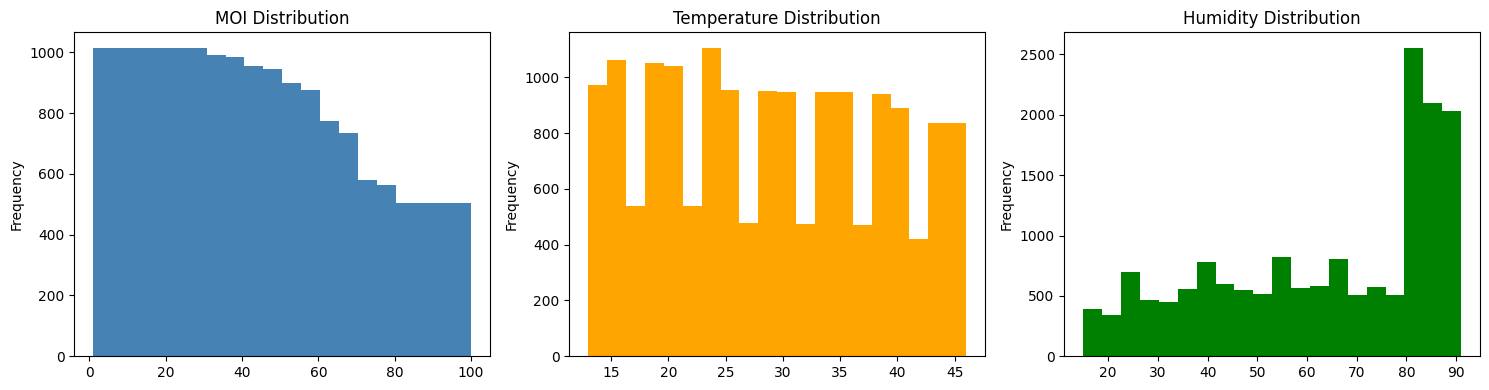

In [9]:
# Distribution of MOI, temperature and humidity
fig, axes = plt.subplots(1, 3, figsize=(15,4))
data['MOI'].plot(kind='hist', bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('MOI Distribution')
data['temp'].plot(kind='hist', bins=20, ax=axes[1], color='orange')
axes[1].set_title('Temperature Distribution')
data['humidity'].plot(kind='hist', bins=20, ax=axes[2], color='green')
axes[2].set_title('Humidity Distribution')
plt.tight_layout()
plt.show()

**6.2 Crop type and irrigation result distribution**

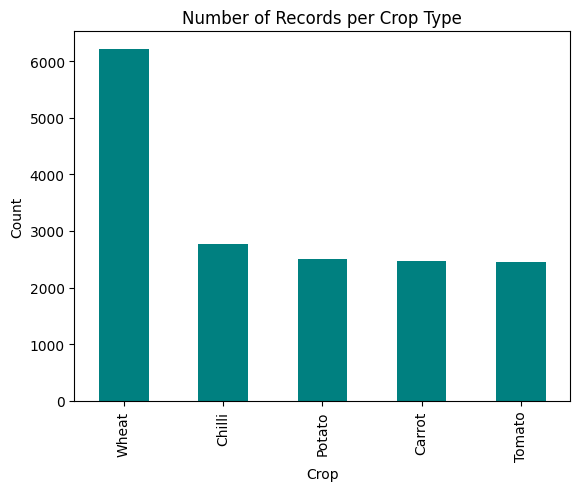

In [10]:
# Distribution of crop types in the dataset
data['crop ID'].value_counts().plot(kind='bar', color='teal')
plt.title('Number of Records per Crop Type')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.show()

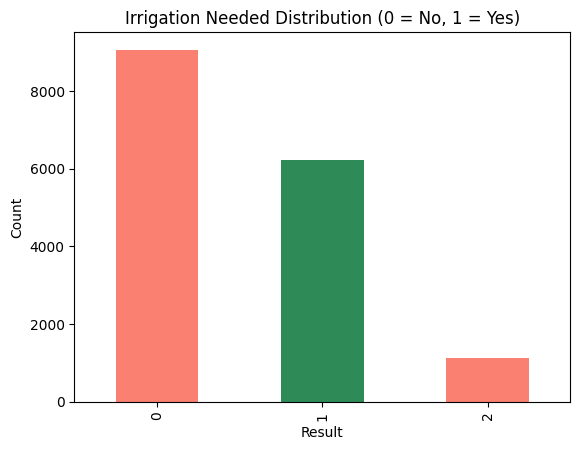

In [11]:
# Distribution of the target variable (irrigation needed or not)
data['result'].value_counts().plot(kind='bar', color=['salmon','seagreen'])
plt.title('Irrigation Needed Distribution (0 = No, 1 = Yes)')
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

**6.3 Correlation between environmental variables**

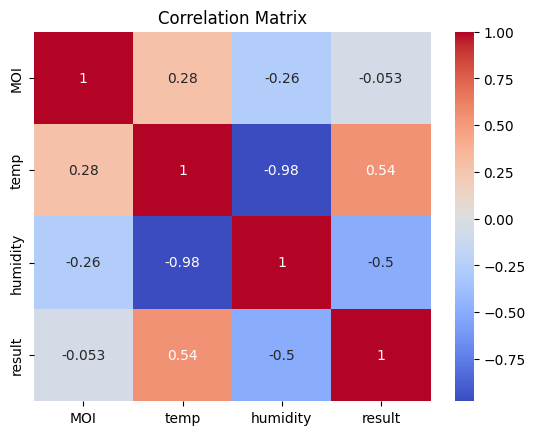

In [12]:
# Correlation matrix between numeric variables
correlation = data[['MOI', 'temp', 'humidity', 'result']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**6.4 MOI vs Result by soil type**

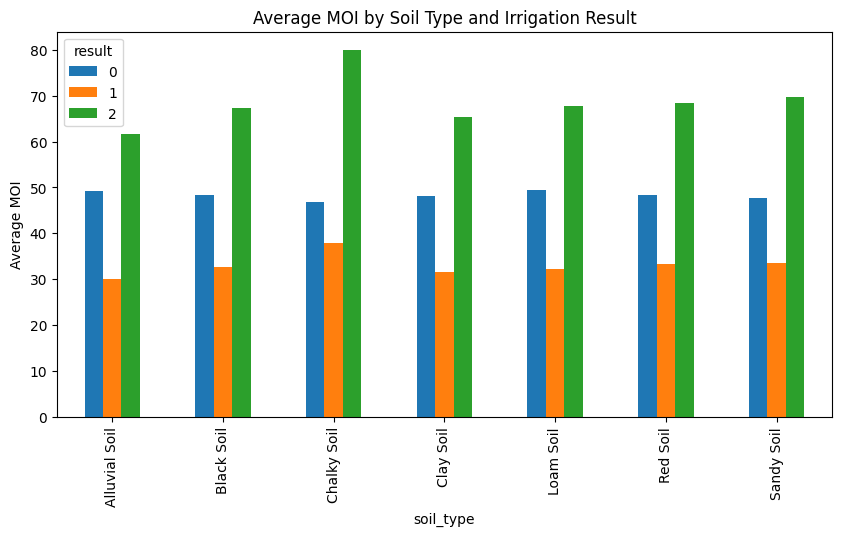

In [13]:
# Average MOI by soil type, separated by irrigation result
data.groupby(['soil_type', 'result'])['MOI'].mean().unstack().plot(kind='bar', figsize=(10,5))
plt.title('Average MOI by Soil Type and Irrigation Result')
plt.ylabel('Average MOI')
plt.show()

To better understand the relationship between environmental conditions and irrigation needs, this section presents a visual exploration of the dataset. First, the distribution of the numeric variables (MOI, temperature, and humidity) is analyzed individually. Then, the dataset is examined by crop type and irrigation outcome to identify how records are distributed across categories. Finally, a correlation analysis is performed to determine which environmental variables have the strongest relationship with the irrigation decision, followed by a comparison of moisture levels across different soil types.

# **The visualizations reveal several important patterns:**

**Distribution of numeric variables (6.1):** The MOI variable shows a slightly right-skewed distribution, with most values concentrated below 60. Temperature is fairly evenly spread between 13°C and 46°C. Humidity is heavily concentrated in the 80-90% range, suggesting that most recorded conditions correspond to high-humidity environments.

**Crop type and irrigation distribution (6.2):** Wheat is by far the most represented crop, with over 6,000 records, more than double any other crop (Chilli, Potato, Carrot, and Tomato each have around 2,500 records). Regarding irrigation, the `result` variable actually contains **three categories instead of two**: 0 (no irrigation, ~9,000 records), 1 (irrigation needed, ~6,200 records), and 2 (a third condition, ~1,100 records), indicating the original binary assumption needs to be revised — this variable may represent a three-level irrigation classification rather than a simple yes/no decision.

**Correlation analysis (6.3):** The strongest relationship in the dataset is between temperature and humidity (-0.98), confirming the expected inverse relationship: as temperature rises, humidity drops sharply. Temperature shows a moderate positive correlation with the irrigation result (0.54), while humidity shows a moderate negative correlation (-0.50). Interestingly, MOI shows almost no linear correlation with the result (-0.053), suggesting that irrigation decisions in this dataset are driven more strongly by temperature and humidity than by the soil moisture index itself.

**MOI by soil type (6.4):** Across all seven soil types, the pattern is consistent: category 2 always has the highest average MOI, category 0 is in the middle, and category 1 has the lowest average MOI. Chalky Soil shows the most pronounced difference between categories, while Alluvial Soil shows the least. This consistency across soil types suggests that the irrigation classification depends more on the combination of temperature/humidity than on soil type alone.

## **7. Key Findings / Conclusions**

This descriptive analysis of the Smart Agriculture Dataset reveals several key insights that are relevant for understanding irrigation needs in agricultural environments:

1. **Temperature and humidity are the dominant environmental drivers.** The correlation analysis shows that these two variables are almost perfectly inversely related (-0.98) and both have a moderate relationship with irrigation needs (0.54 and -0.50 respectively). This confirms the evapotranspiration principle described in the project justification: as temperature increases and humidity decreases, the likelihood of irrigation being required rises.

2. **The irrigation outcome is more complex than a binary decision.** The dataset's `result` variable contains three categories instead of a simple yes/no, with most records falling under "no irrigation" (~9,000) and "irrigation needed" (~6,200), plus a smaller third category (~1,100). This suggests that any future predictive model should be designed as a multi-class classification problem rather than binary classification.

3. **Soil moisture index (MOI) alone is not a strong predictor.** Despite being the primary soil-related variable, MOI shows almost no linear correlation with irrigation outcome (-0.053). However, when segmented by soil type, a consistent pattern emerges across all seven soil types, suggesting that MOI's relationship with irrigation is non-linear and likely interacts with other variables such as soil type and crop stage.

4. **Wheat dominates the dataset representation.** With over 6,000 records compared to roughly 2,500 for each of the other four crops, any future model should account for this imbalance to avoid bias toward Wheat-specific patterns.

These findings establish a solid foundation for the next stage of the project: developing a classification model capable of predicting irrigation requirements based primarily on temperature and humidity, while incorporating soil type and crop stage as contextual features, with potential deployment on lightweight Edge Computing devices for real-time, low-connectivity agricultural environments.

## **8. Forum Collaboration Evidence**

pending upload evidence

## 9. Explanatory Video

pending upload video